##Імпорти

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import os

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

from xgboost import XGBClassifier

import torch
from torch.utils.data import DataLoader
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    DataCollatorWithPadding,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from scipy.special import softmax

import joblib

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
from src.evaluation import evaluate_model

##Завантаження даних

In [ ]:
df = pd.read_parquet("../data/imdb_preprocessed.parquet")
df

,review,sentiment,review_length,clean_review
0,One of the other reviewers has mentioned that ...,positive,307,one reviewer mention watch oz episode youll ho...
1,A wonderful little production. <br /><br />The...,positive,162,wonderful little production film technique una...
2,I thought this was a wonderful way to spend ti...,positive,166,think wonderful way spend time hot summer week...
3,Basically there's a family where a little boy ...,negative,138,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,petter matteis love time money visually stunni...
...,...,...,...,...
49577,I thought this movie did a down right good job...,positive,194,think movie right good job wasnt creative orig...
49578,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,112,bad plot bad dialogue bad act idiotic direct a...
49579,I am a Catholic taught in parochial elementary...,negative,230,catholic teach parochial elementary school nun...
49580,I'm going to have to disagree with the previou...,negative,212,im go disagree previous comment side maltin on...


##Підготовка даних

In [ ]:
X = df["clean_review"]
y = df["sentiment"]

y = y.map({
    "negative": 0,
    "positive": 1
})

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

## TF-IDF

In [ ]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [ ]:
joblib.dump(tfidf, "../models/tfidf_vectorizer.joblib")

In [ ]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3537696 stored elements and shape (34707, 15000)>

In [ ]:
X_val_tfidf = tfidf.transform(X_val)

In [ ]:
X_test_tfidf = tfidf.transform(X_test)

## Навчання моделей

Для виведення метрик будемо використовувати функцію `evaluate_model`.

###Logistic Regression (Baseline)

Як базову модель було обрано Logistic Regression, оскільки вона є одним із найпоширеніших алгоритмів для задач класифікації тексту та добре працює з TF-IDF-представленням ознак. Отримані результати baseline моделі використовуються як точка відліку для подальшого порівняння з іншими алгоритмами класифікації.

In [ ]:
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
baseline_metrics = evaluate_model(baseline_model, X_train_tfidf, y_train, X_val_tfidf, y_val)
baseline_metrics

,Accuracy,F1-score,ROC-AUC
Train,0.9287,0.9295,0.9797
Validation,0.8965,0.8979,0.9621


In [ ]:
baseline_metrics.to_csv("../reports/baseline_lr_results.csv")

Бачимо, що на валідаційній вибірці модель досягла F1-score = 0.8979, Accuracy = 0.8965 та ROC-AUC = 0.9621.

Отримані результати свідчать про високу якість базової моделі. Різниця між метриками на тренувальній та валідаційній вибірках є незначною, що вказує лише на помірне перенавчання та добру здатність моделі до узагальнення. Надалі ці результати будуть використані як базовий рівень для порівняння з іншими алгоритмами класифікації.

Для порівняння було обрано три моделі, що представляють різні підходи до задачі класифікації: Decision Tree, XGBoost та Linear SVM.

Decision Tree використовується як проста інтерпретована модель дерев рішень, XGBoost — як сучасний ансамблевий алгоритм градієнтного бустингу, а Linear SVM — як один із найефективніших методів для класифікації текстових даних. Таке поєднання моделей дозволяє порівняти ефективність різних підходів за однакових вхідних ознак, отриманих за допомогою TF-IDF. Для кожної моделі спочатку буде проведено навчання з базовими параметрами, після чого для моделі з найкращими результатами буде виконано підбір гіперпараметрів.

###Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
evaluate_model(dt_model, X_train_tfidf, y_train, X_val_tfidf, y_val)

,Accuracy,F1-score,ROC-AUC
Train,1.0000,1.0000,1.0000
Validation,0.7139,0.7134,0.7139


Для моделі Decision Tree з параметрами за замовчанням бачимо, що відбулося перенавчання (модель запам'ятала навчальний набір даних). Тому встановимо обмеження на глибину дерева та мінімальну кількість об'єктів у вузлах і листках. Такі параметри дозволять зменшити перенавчання моделі та покращити її здатність до узагальнення на нових даних.

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5
)

dt_model.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(max_depth=20, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [ ]:
evaluate_model(dt_model, X_train_tfidf, y_train, X_val_tfidf, y_val)

,Accuracy,F1-score,ROC-AUC
Train,0.8306,0.8439,0.9061
Validation,0.7348,0.7560,0.7845


Бачимо, що, проблему перенавчання вирішено. Тепер спробуємо декілька значень `max_depth`

In [ ]:
depths = [10, 15, 20, 30]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        random_state=42,
        max_depth=depth,
        min_samples_split=10,
        min_samples_leaf=5
    )

    model.fit(X_train_tfidf, y_train)

    metrics = evaluate_model(
        model,
        X_train_tfidf,
        y_train,
        X_val_tfidf,
        y_val
    )

    results.append({
        "max_depth": depth,
        "Train F1": metrics.loc["Train", "F1-score"],
        "Validation F1": metrics.loc["Validation", "F1-score"],
        "Train ROC-AUC": metrics.loc["Train", "ROC-AUC"],
        "Validation ROC-AUC": metrics.loc["Validation", "ROC-AUC"]
    })

results_df = pd.DataFrame(results)
results_df

,max_depth,Train F1,Validation F1,Train ROC-AUC,Validation ROC-AUC
0,10,0.7852,0.7667,0.8293,0.7997
1,15,0.8170,0.7662,0.8733,0.7955
2,20,0.8439,0.7560,0.9061,0.7845
3,30,0.8778,0.7441,0.9448,0.7709


In [ ]:
dt_best = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)
dt_best.fit(X_train_tfidf, y_train)

dt_best_metrics = evaluate_model(dt_best, X_train_tfidf, y_train, X_val_tfidf, y_val)
dt_best_metrics

,Accuracy,F1-score,ROC-AUC
Train,0.7610,0.7850,0.8288
Validation,0.7394,0.7675,0.7979


In [ ]:
joblib.dump(dt_best,"../models/decision_tree_best.joblib")

['/content/drive/MyDrive/ML/Final Project/Project/models/decision_tree_best.pkl']

In [ ]:
dt_best_metrics.to_csv("../reports/decision_tree_results.csv")

Найкращі результати було отримано при `max_depth` = 15, проте точність цієї моделі все ж таки значно нижче ніж у baseline.

###XGBoost

In [ ]:
xgb_model = XGBClassifier(
    random_state=42,
)
xgb_model.fit(X_train_tfidf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
evaluate_model(xgb_model, X_train_tfidf, y_train, X_val_tfidf,y_val)

,Accuracy,F1-score,ROC-AUC
Train,0.9336,0.9349,0.9838
Validation,0.8524,0.8559,0.9350


Для моделі XGBoost було виконано ручний підбір основних гіперпараметрів (`learning_rate`, `n_estimators`, `max_depth`, `subsample`, `colsample_bytree`) з метою покращення якості класифікації. Найкращі результати на валідаційній вибірці показала модель з параметрами `learning_rate` = 0.05, `n_estimators` = 1000, `max_depth`= 6, `subsample` = 0.8 та `colsample_bytree` = 0.8. Проте навчання цієї моделі було досить довгим (~17 хв.).

In [ ]:
xgb_best = XGBClassifier(
    random_state=42,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    n_jobs=-1
)
xgb_best.fit(X_train_tfidf, y_train)
xgb_best_metrics = evaluate_model(xgb_best, X_train_tfidf, y_train, X_val_tfidf, y_val)
xgb_best_metrics

,Accuracy,F1-score,ROC-AUC
Train,0.9617,0.9622,0.9937
Validation,0.8732,0.8759,0.9488


In [ ]:
joblib.dump(xgb_best,"../models/xgboost_best.joblib")

In [ ]:
xgb_best_metrics.to_csv("../reports/xgboost_results.csv")

###Linear SVM

In [ ]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [ ]:
evaluate_model(svm_model, X_train_tfidf, y_train, X_val_tfidf, y_val)

,Accuracy,F1-score,ROC-AUC
Train,0.9763,0.9765,0.9972
Validation,0.8923,0.8928,0.9581


### Порівняння результатів

Серед протестованих моделей найкращі результати на валідаційній вибірці показала Logistic Regression (Baseline), яка досягла значення F1-score 0.8979 та ROC-AUC 0.9621. Linear SVM продемонструвала співставну якість із F1-score 0.8928, тоді як XGBoost після ручного підбору гіперпараметрів показав дещо нижчий результат (F1-score 0.8741), що свідчить про перевагу лінійних моделей для задач класифікації текстів із TF-IDF представленням. Decision Tree показала найгірші результати (F1-score 0.7667), що пов’язано скоріш за все з високою розмірністю текстових ознак та схильністю дерев рішень до перенавчання на таких даних.

###Тюнинг гіперпараметрів

Враховуючи отримані результати, будемо робити тюнинг гіперпараметрів для наступних моделей: Logistic Regression (Baseline) та Linear SVM. Також для моделі з найкращими результатами зробимо додактовий тюнинг TF-IDF.

#### Logistic Regression (Baseline)

In [ ]:
lr_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", LogisticRegression(max_iter=1000))
])


param_grid_lr = {

    "model__C": [0.01, 0.1, 0.5, 1, 2, 5, 10],
    "model__class_weight": [None, "balanced"]
}


grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=1,
    verbose=2,
    return_train_score=True
)


grid_lr.fit(X_train, y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV] END ............model__C=0.01, model__class_weight=None; total time=  20.4s
[CV] END ............model__C=0.01, model__class_weight=None; total time=  19.4s
[CV] END ............model__C=0.01, model__class_weight=None; total time=  19.3s
[CV] END ............model__C=0.01, model__class_weight=None; total time=  18.4s
[CV] END ............model__C=0.01, model__class_weight=None; total time=  18.8s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=  19.3s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=  18.8s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=  19.3s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=  19.5s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=  19.0s
[CV] END .............model__C=0.1, model__class_weight=None; total time=  20.8s
[CV] END .............model__C=0.1, model__class

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=15000,
                                                        min_df=3,
                                                        ngram_range=(1, 2),
                                                        sublinear_tf=True)),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=1,
             param_grid={'model__C': [0.01, 0.1, 0.5, 1, 2, 5, 10],
                         'model__class_weight': [None, 'balanced']},
             return_train_score=True, scoring='f1', verbose=2)

In [ ]:
grid_lr.best_params_

{'model__C': 2, 'model__class_weight': 'balanced'}

In [ ]:
lr_best = grid_lr.best_estimator_
joblib.dump(lr_best, "../models/logistic_regression_best.joblib")

['/content/drive/MyDrive/ML/Final Project/Project/models/logistic_regression_best.joblib']

In [ ]:
lr_best_metrics = evaluate_model(lr_best, X_train, y_train, X_val, y_val)
lr_best_metrics

,Accuracy,F1-score,ROC-AUC
Train,0.9435,0.9440,0.9859
Validation,0.8997,0.9008,0.9632


####Linear SVM

In [ ]:
svm_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", LinearSVC())
])

param_grid_svm = {
    "model__C": [0.01, 0.1, 0.5, 1, 2, 5, 10],
    "model__class_weight": [None, "balanced"]
}


grid_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=5,
    scoring="f1",
    n_jobs=1,
    verbose=2
)


grid_svm.fit(X_train, y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV] END ............model__C=0.01, model__class_weight=None; total time=  19.6s
[CV] END ............model__C=0.01, model__class_weight=None; total time=  18.7s
[CV] END ............model__C=0.01, model__class_weight=None; total time=  19.5s
[CV] END ............model__C=0.01, model__class_weight=None; total time=  20.1s
[CV] END ............model__C=0.01, model__class_weight=None; total time=  20.4s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=  20.0s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=  19.8s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=  19.7s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=  21.5s
[CV] END ........model__C=0.01, model__class_weight=balanced; total time=  21.1s
[CV] END .............model__C=0.1, model__class_weight=None; total time=  20.5s
[CV] END .............model__C=0.1, model__class

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=15000,
                                                        min_df=3,
                                                        ngram_range=(1, 2),
                                                        sublinear_tf=True)),
                                       ('model', LinearSVC())]),
             n_jobs=1,
             param_grid={'model__C': [0.01, 0.1, 0.5, 1, 2, 5, 10],
                         'model__class_weight': [None, 'balanced']},
             scoring='f1', verbose=2)

In [ ]:
grid_svm.best_params_

{'model__C': 0.1, 'model__class_weight': 'balanced'}

In [ ]:
svm_best = grid_svm.best_estimator_
joblib.dump(svm_best, "../models/Linear SVM.joblib")

['/content/drive/MyDrive/ML/Final Project/Project/models/Linear SVM.joblib']

In [ ]:
svm_best = joblib.load("../models/Linear SVM.joblib")

In [ ]:
svm_best_metrics = evaluate_model(svm_best, X_train, y_train, X_val, y_val)
svm_best_metrics

,Accuracy,F1-score,ROC-AUC
Train,0.9329,0.9337,0.9817
Validation,0.8979,0.8994,0.9628


In [ ]:
svm_best_metrics.to_csv("../reports/linear_svm_results.csv")

#### Порівняння моделей після тюнінгу гіперпараметрів

Після підбору гіперпараметрів обидві моделі продемонстрували покращення якості класифікації. Logistic Regression підвищила значення F1-score на валідаційній вибірці з 0.8979 до 0.9008, а ROC-AUC — з 0.9621 до 0.9632. Linear SVM також покращила свої результати: F1-score зріс з 0.8928 до 0.8994, а ROC-AUC — до 0.9628. Незважаючи на позитивний вплив оптимізації, Logistic Regression зберегла найкращу якість серед усіх досліджених моделей та була обрана як фінальна модель для подальшого оцінювання на тестовій вибірці.

####TF-IDF

In [ ]:
tfidf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        sublinear_tf=True
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        C=grid_lr.best_params_["model__C"],
        class_weight=grid_lr.best_params_["model__class_weight"]
    ))
])

param_grid_tfidf = {
    "tfidf__max_features": [10000, 15000, 20000],
    "tfidf__min_df": [2, 3],
}

grid_tfidf = GridSearchCV(
    tfidf_pipeline,
    param_grid_tfidf,
    cv=5,
    scoring="f1",
    n_jobs=1,
    verbose=2
)


grid_tfidf.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END .........tfidf__max_features=10000, tfidf__min_df=2; total time=  20.4s
[CV] END .........tfidf__max_features=10000, tfidf__min_df=2; total time=  24.4s
[CV] END .........tfidf__max_features=10000, tfidf__min_df=2; total time=  21.0s
[CV] END .........tfidf__max_features=10000, tfidf__min_df=2; total time=  23.0s
[CV] END .........tfidf__max_features=10000, tfidf__min_df=2; total time=  22.2s
[CV] END .........tfidf__max_features=10000, tfidf__min_df=3; total time=  20.0s
[CV] END .........tfidf__max_features=10000, tfidf__min_df=3; total time=  19.5s
[CV] END .........tfidf__max_features=10000, tfidf__min_df=3; total time=  22.3s
[CV] END .........tfidf__max_features=10000, tfidf__min_df=3; total time=  19.4s
[CV] END .........tfidf__max_features=10000, tfidf__min_df=3; total time=  20.0s
[CV] END .........tfidf__max_features=15000, tfidf__min_df=2; total time=  20.6s
[CV] END .........tfidf__max_features=15000, tfid

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(ngram_range=(1, 2),
                                                        sublinear_tf=True)),
                                       ('model',
                                        LogisticRegression(C=2,
                                                           class_weight='balanced',
                                                           max_iter=1000))]),
             n_jobs=1,
             param_grid={'tfidf__max_features': [10000, 15000, 20000],
                         'tfidf__min_df': [2, 3]},
             scoring='f1', verbose=2)

In [ ]:
grid_tfidf.best_params_

{'tfidf__max_features': 20000, 'tfidf__min_df': 3}

In [ ]:
tfidf_best = grid_tfidf.best_estimator_
joblib.dump(tfidf_best, "../models/LR_TFIDF_GSCV.joblib")

['/content/drive/MyDrive/ML/Final Project/Project/models/LR_TFIDF_GSCV.joblib']

In [ ]:
tfidf_best = joblib.load("../models/LR_TFIDF_GSCV.joblib")

In [ ]:
tfidf_tuned_metrics = evaluate_model(tfidf_best, X_train, y_train, X_val, y_val,X_test=X_test, y_test=y_test)
tfidf_tuned_metrics

,Accuracy,F1-score,ROC-AUC
Train,0.9476,0.9481,0.9877
Validation,0.9009,0.9019,0.9633
Test,0.8953,0.8969,0.9611


In [ ]:
tfidf_tuned_metrics.to_csv("../reports/tfidf_tuned_lr_results.csv")

Після оптимізації параметрів TF-IDF було досягнуто додаткового покращення якості моделі Logistic Regression:
- Значення F1-score на валідаційній вибірці зросло з 0.9008 до 0.9019
- ROC-AUC на валідаційній вибірці зросло з 0.9628 до 0.9633.
- Отримані метрики на тестовій вибірці підтверджують стабільність моделі та відсутність суттєвого перенавчання, однак вплив оптимізації TF-IDF на загальну якість класифікації виявився незначним.

Це свідчить про те, що налаштування параметрів векторизації тексту також впливає на якість класифікації, хоча отриманий приріст є незначним. За сукупністю результатів найкращою моделлю було обрано Logistic Regression із підібраними гіперпараметрами моделі та TF-IDF.

Отримані метрики на тестовій вибірці підтверджують стабільність моделі та відсутність суттєвого перенавчання, однак вплив оптимізації TF-IDF на загальну якість класифікації виявився незначним.

#### Аналіз важливості ознак

In [ ]:
vectorizer = tfidf_best.named_steps["tfidf"]
model = tfidf_best.named_steps["model"]

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

top_positive = feature_importance.sort_values(
    by="coefficient",
    ascending=False
).head(20)

top_negative = feature_importance.sort_values(
    by="coefficient",
    ascending=True
).head(20)

print("Top 20 Positive Features")
display(top_positive)

print("Top 20 Negative Features")
display(top_negative)

Top 20 Positive Features


,feature,coefficient
7481,great,8.889836
5386,excellent,7.719532
13145,perfect,6.488802
19542,wonderful,5.436405
10214,love,5.396261
5714,favorite,5.328734
1574,best,5.248395
1967,brilliant,5.149655
17968,today,5.117200
12468,one best,5.074598


Top 20 Negative Features


,feature,coefficient
1226,bad,-12.382591
1162,awful,-9.128043
18984,waste,-8.462350
17401,terrible,-6.878052
13547,poor,-6.739571
19639,worst,-6.507687
1854,boring,-6.180699
8195,horrible,-6.075510
1849,bore,-6.070490
12252,nothing,-5.906600


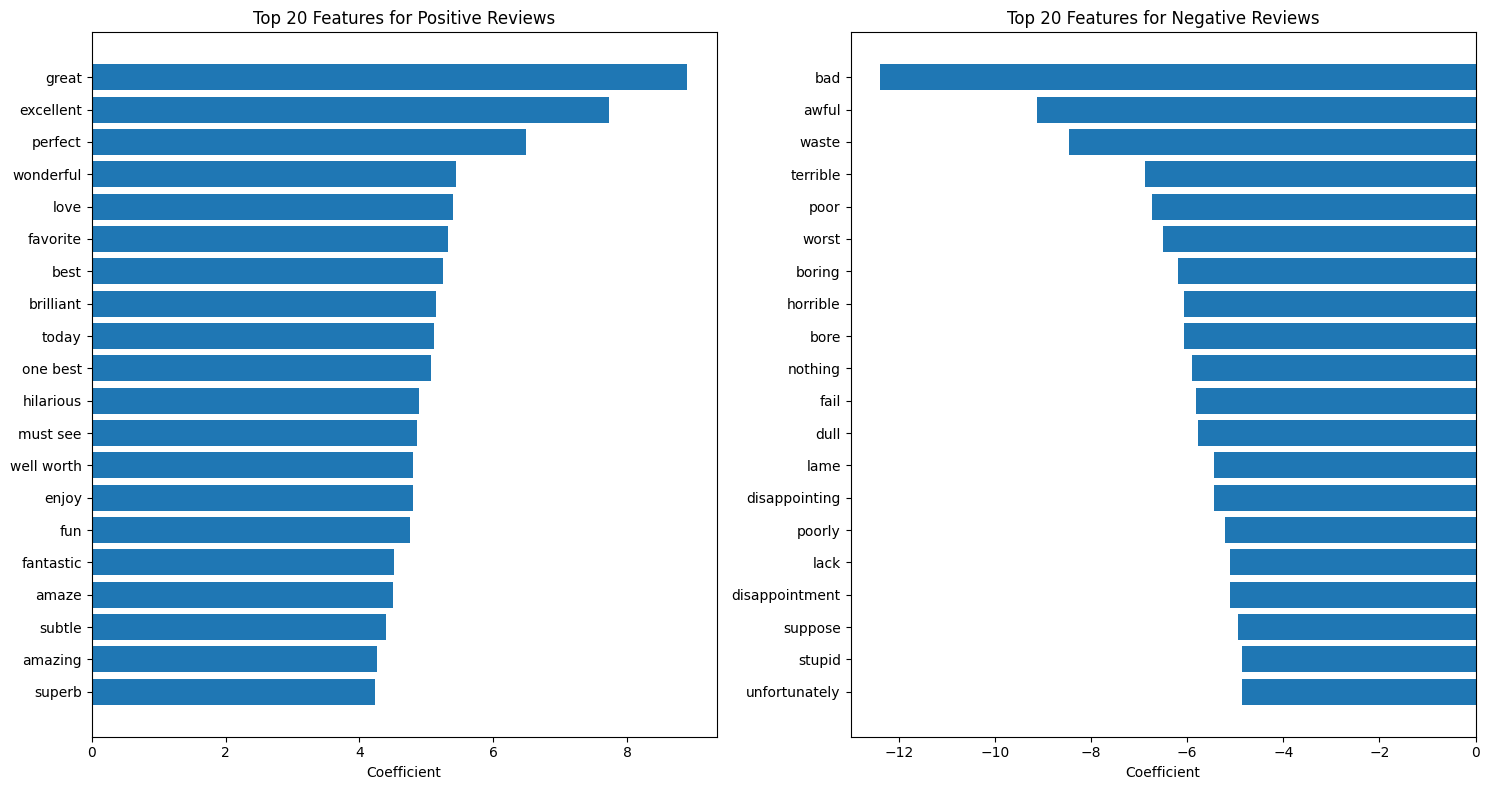

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Positive
axes[0].barh(
    top_positive["feature"],
    top_positive["coefficient"]
)
axes[0].set_title("Top 20 Features for Positive Reviews")
axes[0].invert_yaxis()
axes[0].set_xlabel("Coefficient")

# Negative
axes[1].barh(
    top_negative["feature"],
    top_negative["coefficient"]
)
axes[1].invert_yaxis()
axes[1].set_title("Top 20 Features for Negative Reviews")
axes[1].set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

 Дивлячись на візуалізацію важливості ознак, бачимо, що:
 - серед найважливіших ознак для позитивного класу переважають слова з вираженим позитивним емоційним забарвленням, такі як `great`, `excellent`, `perfect`, `wonderful` та `love`;
 - натомість найбільший вплив на прогнозування негативних відгуків мають слова `bad`, `awful`, `waste`, `terrible` та `worst`
 - серед найважливіших ознак зустрічаються й окремі нейтральні слова, зокрема `today`, `subtle` та `suppose`. Їхня висока вага, ймовірно, пояснюється частим використанням у певному контексті позитивних або негативних відгуків у навчальній вибірці, а не власним емоційним забарвленням.

 Отримані результати свідчать, що модель навчається на змістовних ознаках, які добре відображають емоційне забарвлення тексту, а її рішення є логічними та легко інтерпретуються.

###DistilBERT

Тепер порівняємо наші результати, отримані за допомогою класичної ML-моделі з тюнингом гіперпараметрів, з трансформерною моделлю DistilBERT.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
MODEL_NAME = "distilbert-base-uncased"

In [ ]:
train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

val_dataset = Dataset.from_dict({
    "text": X_val.tolist(),
    "label": y_val.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True
    )

In [ ]:
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/34707 [00:00<?, ? examples/s]

Map:   0%|          | 0/7437 [00:00<?, ? examples/s]

Map:   0%|          | 0/7438 [00:00<?, ? examples/s]

In [ ]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probabilities = softmax(logits, axis=1)
    predictions = np.argmax(probabilities, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions),
        "roc_auc": roc_auc_score(labels, probabilities[:, 1]),
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./distilbert_results",

    num_train_epochs=3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=100,
    logging_first_step=True,

    save_total_limit=1,

    fp16=True,

    report_to="none",

    seed=42
)

In [ ]:
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2
)

In [ ]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[early_stopping]
)

In [ ]:
MODEL_DIR = "../models/distilbert"
os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:
trainer.train()

In [ ]:
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

In [ ]:
train_predictions = trainer.predict(train_dataset)
train_metrics = train_predictions.metrics

In [ ]:
val_metrics = trainer.evaluate()
print(val_metrics)

In [ ]:
test_predictions = trainer.predict(test_dataset)

In [ ]:
results_BERT = pd.DataFrame(
    {
        "Accuracy": [
            val_metrics["eval_accuracy"],
            test_predictions.metrics["test_accuracy"],
        ],
        "F1-score": [
            val_metrics["eval_f1"],
            test_predictions.metrics["test_f1"],
        ],
        "ROC-AUC": [
            val_metrics["eval_roc_auc"],
            test_predictions.metrics["test_roc_auc"],
        ],
    },
    index=["Validation", "Test"],
)

results_BERT

In [ ]:
results_BERT.to_csv("../reports/distilbert_results.csv", index=False)

In [ ]:
BERT_metrics = pd.read_csv("../reports/distilbert_results.csv", index_col=0)
BERT_metrics

,Accuracy,F1-score,ROC-AUC
Train,0.972859,0.973298,0.994656
Validation,0.910044,0.912423,0.970768
Test,0.903603,0.906628,0.966489


DistilBERT показала найкращі результати серед усіх досліджених моделей. Високі та близькі значення метрик на тренувальній, валідаційній та тестовій вибірках свідчать про ефективність моделі та її хорошу здатність до узагальнення без помітного перенавчання.

## Результати

In [ ]:
summary_results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression (Baseline)",
            "Decision Tree",
            "XGBoost",
            "Linear SVM",
            "Logistic Regression + TF-IDF tuning",
            "DistilBERT",
        ],

        "Train F1-score": [
            baseline_metrics.loc["Train", "F1-score"],
            dt_best_metrics.loc["Train", "F1-score"],
            xgb_best_metrics.loc["Train", "F1-score"],
            svm_best_metrics.loc["Train", "F1-score"],
            tfidf_tuned_metrics.loc["Train", "F1-score"],
            BERT_metrics.loc["Train", "F1-score"],
        ],

        "Validation F1-score": [
            baseline_metrics.loc["Validation", "F1-score"],
            dt_best_metrics.loc["Validation", "F1-score"],
            xgb_best_metrics.loc["Validation", "F1-score"],
            svm_best_metrics.loc["Validation", "F1-score"],
            tfidf_tuned_metrics.loc["Validation", "F1-score"],
            BERT_metrics.loc["Validation", "F1-score"],
        ],

        "Test F1-score": [
            "-",
            "-",
            "-",
            "-",
            tfidf_tuned_metrics.loc["Test", "F1-score"],
            BERT_metrics.loc["Test", "F1-score"],
        ],

        "Training time": [
            "1 с",
            "9 с",
            "17 хв",
            "23 с",
            "23 с",
            "18 хв",
        ],
    }
)

summary_results

,Model,Train F1-score,Validation F1-score,Test F1-score,Training time
0,Logistic Regression (Baseline),0.929500,0.897900,-,1 с
1,Decision Tree,0.785000,0.767500,-,9 с
2,XGBoost,0.962200,0.875900,-,17 хв
3,Linear SVM,0.933700,0.899400,-,23 с
4,Logistic Regression + TF-IDF tuning,0.948100,0.901900,0.8969,23 с
5,DistilBERT,0.973298,0.912423,0.906628,18 хв


In [ ]:
summary_results.insert(
    1,
    "Key hyperparameters",
    [
        "max_iter=1000",
        "max_depth=10, min_samples_leaf=5",
        "n_estimators=1000, learning_rate=0.05, max_depth=6",
        "C=0.1, class_weight=balanced",
        "LR: C=2, class_weight=balanced; TF-IDF: max_features=20000, min_df=3",
        "-"
    ]
)

In [ ]:
summary_results.to_csv("../reports/summary_results.csv", index=False)
summary_results = pd.read_csv("../reports/summary_results.csv")
summary_results

,Model,Key hyperparameters,Train F1-score,Validation F1-score,Test F1-score,Training time
0,Logistic Regression (Baseline),max_iter=1000,0.929500,0.897900,-,1 с
1,Decision Tree,"max_depth=10, min_samples_leaf=5",0.785000,0.767500,-,9 с
2,XGBoost,"n_estimators=1000, learning_rate=0.05, max_dep...",0.962200,0.875900,-,17 хв
3,Linear SVM,"C=0.1, class_weight=balanced",0.933700,0.899400,-,23 с
4,Logistic Regression + TF-IDF tuning,"LR: C=2, class_weight=balanced; TF-IDF: max_fe...",0.948100,0.901900,0.8969,23 с
5,DistilBERT,-,0.973298,0.912423,0.9066284672483396,18 хв


##Висновки

- Серед класичних моделей найкращі результати продемонструвала Logistic Regression після оптимізації параметрів TF-IDF та самої моделі, досягнувши F1-score 0.9019 на валідаційній вибірці та 0.8969 на тестовій. Це підтверджує, що лінійні моделі добре працюють із розрідженими TF-IDF ознаками та забезпечують високу якість класифікації при невеликих обчислювальних витратах. Найкращий загальний результат отримала модель DistilBERT, яка досягла F1-score 0.9124 на валідаційній та 0.9066 на тестовій вибірці. Перевага DistilBERT пояснюється використанням контекстних мовних представлень, що дозволяють краще враховувати зміст і семантичні зв'язки між словами.
- Дослідження показало, що для задачі аналізу тональності тексту правильно налаштована Logistic Regression із TF-IDF може перевершувати значно складніші моделі, такі як XGBoost. Водночас використання трансформерної моделі DistilBERT дозволило отримати найкращу якість класифікації завдяки врахуванню контексту тексту. Це підтверджує, що вибір моделі повинен залежати не лише від її складності, а й від особливостей даних та вимог до швидкості й точності.
- Модель може використовуватися для автоматичного аналізу відгуків клієнтів, моніторингу репутації бренду та оцінки задоволеності споживачів. Це дозволяє швидко виявляти негативні відгуки, аналізувати настрої користувачів і приймати обґрунтовані бізнес-рішення.
- Якість класифікації залежить від даних, на яких навчалася модель, тому вона може гірше працювати з відгуками іншої тематики або текстами, що містять сарказм, іронію чи неоднозначний контекст. Крім того, модель DistilBERT потребує значно більше обчислювальних ресурсів і часу для навчання та використання порівняно з класичними алгоритмами.
- Для Logistic Regression перспективним напрямом є подальша оптимізація параметрів TF-IDF та самої моделі, що може забезпечити додаткове покращення якості класифікації. Для DistilBERT доцільно дослідити вплив кількості епох, параметрів навчання, а також протестувати потужніші трансформерні моделі, такі як BERT або RoBERTa. Крім того, можна розширити порівняння, додавши інші сучасні моделі для аналізу тональності тексту.